# Day 3 · AI: Text is Data — Turning Words into Numbers

> **Context**: Machines don't read words. They read numbers. Preprocessing is the first transformation that turns raw human language into something a model can learn from.
> 
> **Real-World Impact**: Every NLP system — search engines, chatbots, classification pipelines — starts with tokenization and text preprocessing. Get this wrong and the rest of the pipeline collapses.

---

## 🎯 Day 3 Objectives
1. **Tokenize** paragraphs and sentences using **NLTK** and **spaCy**.
2. **Remove stop words** and **punctuation** from sample texts to isolate semantic tokens.
3. **Convert tokens into a Bag-of-Words (BoW)** representation (custom dictionary implementation + `scikit-learn` `CountVectorizer`).
4. **Export a ML-ready preprocessed dataset** (`preprocessed_dataset.csv`).


## 🛠️ Step 0: Setup & Imports

In [1]:
import string
import json
import ssl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords

import spacy
from sklearn.feature_extraction.text import CountVectorizer

# Handle SSL certificate setup for NLTK downloads on macOS
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Load spaCy English Model
try:
    nlp = spacy.load("en_core_web_sm")
    print("✓ spaCy en_core_web_sm model loaded successfully.")
except Exception as e:
    print("Error loading spaCy model:", e)

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Helvetica'


✓ spaCy en_core_web_sm model loaded successfully.


## 📄 Step 1: Sample Paragraph Corpus

Let's define a sample text corpus representing human natural language input.


In [2]:
sample_paragraph = (
    "Machines don't read words. They read numbers. Preprocessing is the first transformation "
    "that turns raw human language into something a model can learn from! Every NLP system - search, "
    "chatbots, classification - starts with tokenization and preprocessing. Get this wrong and the rest "
    "of the pipeline collapses."
)

corpus = [
    "Machines don't read words. They read numbers. Preprocessing is the first transformation that turns raw human language into something a model can learn from!",
    "Every NLP system - search engines, chatbots, text classification - starts with tokenization and text preprocessing. Get this wrong and the rest of the pipeline collapses.",
    "Tokenization breaks paragraphs into sentences and words, removing stop words like 'is', 'the', and 'and', along with punctuation marks.",
    "Bag-of-Words converts cleaned text tokens into numerical vectors representing word frequency counts for machine learning algorithms."
]

print("--- Sample Paragraph ---")
print(sample_paragraph)


--- Sample Paragraph ---
Machines don't read words. They read numbers. Preprocessing is the first transformation that turns raw human language into something a model can learn from! Every NLP system - search, chatbots, classification - starts with tokenization and preprocessing. Get this wrong and the rest of the pipeline collapses.


## ✂️ Step 2: Tokenization (NLTK vs spaCy)

**Tokenization** splits continuous text into discrete units (tokens) such as words, punctuation, or sentences.

- **Sentence Tokenization**: Splitting text into individual sentences.
- **Word Tokenization**: Splitting sentences into individual words/symbols.


In [3]:
# 1. NLTK Tokenization
nltk_sentences = sent_tokenize(sample_paragraph)
nltk_words = word_tokenize(sample_paragraph)

print(f"--- NLTK Tokenization ---")
print(f"Sentence Count: {len(nltk_sentences)}")
print(f"Word Token Count: {len(nltk_words)}")
print(f"First 15 Word Tokens: {nltk_words[:15]}\n")

# 2. spaCy Tokenization
doc = nlp(sample_paragraph)
spacy_sentences = [sent.text for sent in doc.sents]
spacy_words = [token.text for token in doc]

print(f"--- spaCy Tokenization ---")
print(f"Sentence Count: {len(spacy_sentences)}")
print(f"Word Token Count: {len(spacy_words)}")
print(f"First 15 Word Tokens: {spacy_words[:15]}")


--- NLTK Tokenization ---
Sentence Count: 5
Word Token Count: 55
First 15 Word Tokens: ['Machines', 'do', "n't", 'read', 'words', '.', 'They', 'read', 'numbers', '.', 'Preprocessing', 'is', 'the', 'first', 'transformation']

--- spaCy Tokenization ---
Sentence Count: 5
Word Token Count: 55
First 15 Word Tokens: ['Machines', 'do', "n't", 'read', 'words', '.', 'They', 'read', 'numbers', '.', 'Preprocessing', 'is', 'the', 'first', 'transformation']


/var/folders/1x/cvjbl8cn0nv0gvwfvyqzm2rh0000gn/T/ipykernel_37865/4025527440.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=token_comparison_df, x="Framework", y="Word Token Count", palette=["#2563eb", "#7c3aed"], ax=ax)


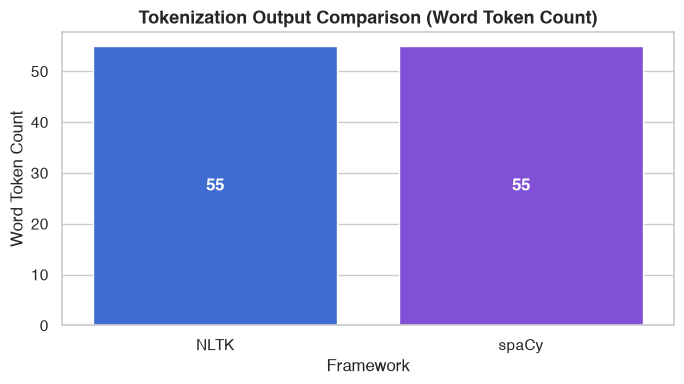

In [4]:
# Visualizing Token Breakdown
token_comparison_df = pd.DataFrame({
    "Framework": ["NLTK", "spaCy"],
    "Sentence Count": [len(nltk_sentences), len(spacy_sentences)],
    "Word Token Count": [len(nltk_words), len(spacy_words)]
})

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=token_comparison_df, x="Framework", y="Word Token Count", palette=["#2563eb", "#7c3aed"], ax=ax)
ax.set_title("Tokenization Output Comparison (Word Token Count)", fontsize=13, fontweight='bold')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')
plt.tight_layout()
plt.show()


## 🧹 Step 3: Removing Stop Words & Punctuation

- **Stop Words**: Extremely common words (e.g. *is, the, and, in, of*) that carry little semantic signal for classification.
- **Punctuation**: Non-alphanumeric characters (e.g. *., !, -, ?*) that do not represent words.
- **Lowercasing**: Converting words to uniform lowercase so `"Preprocessing"` and `"preprocessing"` match.


In [5]:
stop_words = set(stopwords.words('english'))
punctuation_set = set(string.punctuation)

print(f"Sample NLTK Stop Words ({len(stop_words)} total): {list(stop_words)[:10]}")
print(f"Punctuation Set: {' '.join(punctuation_set)}")


Sample NLTK Stop Words (198 total): ['doesn', 'being', "we'll", 'when', 'from', "needn't", 'during', 'this', 'up', 'his']
Punctuation Set: \ : ! | @ = < ' ] . { > } / ( , " _ ? $ ) ^ ; + % ` & * ~ [ # -


In [6]:
def clean_tokens(tokens):
    cleaned = []
    removed = []
    for t in tokens:
        lowered = t.lower()
        if lowered in punctuation_set:
            removed.append((t, 'Punctuation'))
        elif lowered in stop_words:
            removed.append((t, 'Stop Word'))
        elif not lowered.isalnum():
            removed.append((t, 'Special Symbol'))
        else:
            cleaned.append(lowered)
    return cleaned, removed

cleaned_nltk_tokens, removed_nltk_info = clean_tokens(nltk_words)

print("--- BEFORE Preprocessing ---")
print(f"Raw Token Count: {len(nltk_words)}")
print(f"Tokens: {nltk_words[:20]}...")

print("\n--- AFTER Preprocessing ---")
print(f"Cleaned Token Count: {len(cleaned_nltk_tokens)}")
print(f"Tokens: {cleaned_nltk_tokens[:20]}...")
print(f"Tokens Removed: {len(removed_nltk_info)} ({len(removed_nltk_info)/len(nltk_words):.1%} reduction)")


--- BEFORE Preprocessing ---
Raw Token Count: 55
Tokens: ['Machines', 'do', "n't", 'read', 'words', '.', 'They', 'read', 'numbers', '.', 'Preprocessing', 'is', 'the', 'first', 'transformation', 'that', 'turns', 'raw', 'human', 'language']...

--- AFTER Preprocessing ---
Cleaned Token Count: 29
Tokens: ['machines', 'read', 'words', 'read', 'numbers', 'preprocessing', 'first', 'transformation', 'turns', 'raw', 'human', 'language', 'something', 'model', 'learn', 'every', 'nlp', 'system', 'search', 'chatbots']...
Tokens Removed: 26 (47.3% reduction)


  Document  Raw Tokens  Cleaned Tokens  Removed
0    Doc 1          28              15       13
1    Doc 2          30              17       13
2    Doc 3          30              12       18
3    Doc 4          17              13        4


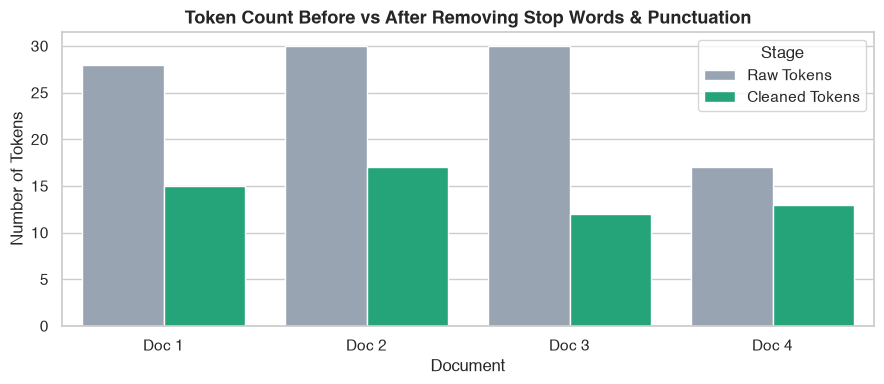

In [7]:
# Before vs After Visualization across Corpus
corpus_analysis = []
for idx, doc_text in enumerate(corpus, 1):
    raw_toks = word_tokenize(doc_text)
    clean_toks, _ = clean_tokens(raw_toks)
    corpus_analysis.append({
        "Document": f"Doc {idx}",
        "Raw Tokens": len(raw_toks),
        "Cleaned Tokens": len(clean_toks),
        "Removed": len(raw_toks) - len(clean_toks)
    })

corpus_df = pd.DataFrame(corpus_analysis)
print(corpus_df)

# Plotting Before vs After
plt.figure(figsize=(9, 4))
df_melted = corpus_df.melt(id_vars="Document", value_vars=["Raw Tokens", "Cleaned Tokens"], var_name="Stage", value_name="Count")
sns.barplot(data=df_melted, x="Document", y="Count", hue="Stage", palette=["#94a3b8", "#10b981"])
plt.title("Token Count Before vs After Removing Stop Words & Punctuation", fontsize=13, fontweight='bold')
plt.ylabel("Number of Tokens")
plt.tight_layout()
plt.show()


## 🔢 Step 4: Bag-of-Words (BoW) Representation

**Bag-of-Words** converts unstructured text tokens into fixed-length numerical vectors:
1. **Vocabulary Construction**: Build a set of all unique words across the entire corpus.
2. **Frequency Count Vector**: For each document, count how many times each vocabulary word appears.


In [8]:
# 1. Scikit-Learn CountVectorizer Implementation
cleaned_corpus_strings = [" ".join(clean_tokens(word_tokenize(doc_text))[0]) for doc_text in corpus]

vectorizer = CountVectorizer()
bow_matrix_sklearn = vectorizer.fit_transform(cleaned_corpus_strings)
feature_names = vectorizer.get_feature_names_out()

bow_df = pd.DataFrame(bow_matrix_sklearn.toarray(), index=[f"Doc {i+1}" for i in range(len(corpus))], columns=feature_names)

print(f"Vocabulary Size: {len(feature_names)} unique words\n")
print("--- Bag-of-Words Matrix Preview (First 12 Features) ---")
display(bow_df.iloc[:, :12])


Vocabulary Size: 50 unique words

--- Bag-of-Words Matrix Preview (First 12 Features) ---


,algorithms,along,breaks,chatbots,classification,cleaned,collapses,converts,counts,engines,every,first
Doc 1,0,0,0,0,0,0,0,0,0,0,0,1
Doc 2,0,0,0,1,1,0,1,0,0,1,1,0
Doc 3,0,1,1,0,0,0,0,0,0,0,0,0
Doc 4,1,0,0,0,0,1,0,1,1,0,0,0


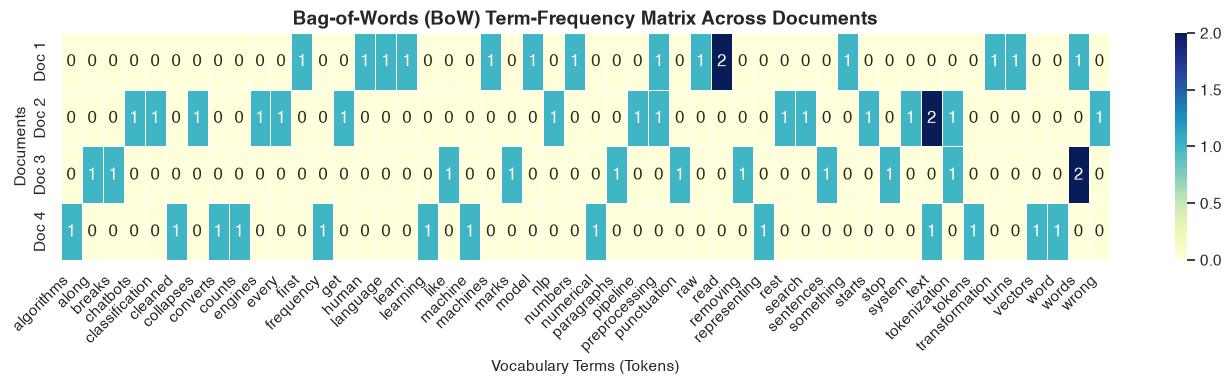

In [9]:
# Visualizing Bag-of-Words Matrix as Heatmap
plt.figure(figsize=(14, 4))
sns.heatmap(bow_df, annot=True, cbar=True, cmap="YlGnBu", linewidths=0.5, fmt="d")
plt.title("Bag-of-Words (BoW) Term-Frequency Matrix Across Documents", fontsize=14, fontweight='bold')
plt.xlabel("Vocabulary Terms (Tokens)", fontsize=11)
plt.ylabel("Documents", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 💾 Step 5: Exporting Preprocessed ML-Ready Dataset

Finally, we bundle raw texts, extracted tokens, cleaned tokens, and Bag-of-Words feature vectors into a single machine-learning-ready dataset (`preprocessed_dataset.csv`).


In [10]:
# Constructing Dataset DataFrame
export_rows = []
for i, raw_text in enumerate(corpus, 1):
    raw_toks = word_tokenize(raw_text)
    clean_toks, _ = clean_tokens(raw_toks)
    spacy_doc = nlp(raw_text)
    spacy_toks = [token.lemma_.lower() for token in spacy_doc if not token.is_stop and not token.is_punct and not token.is_space]
    
    export_rows.append({
        "doc_id": f"Doc_{i}",
        "raw_text": raw_text,
        "raw_token_count": len(raw_toks),
        "nltk_raw_tokens": json.dumps(raw_toks),
        "cleaned_token_count": len(clean_toks),
        "cleaned_tokens": json.dumps(clean_toks),
        "spacy_lemmatized_tokens": json.dumps(spacy_toks),
        "cleaned_text": " ".join(clean_toks),
        "bow_vector": json.dumps(bow_df.iloc[i-1].values.tolist())
    })

dataset_df = pd.DataFrame(export_rows)

# Export to CSV
dataset_df.to_csv("preprocessed_dataset.csv", index=False)

print("✓ Preprocessed dataset successfully created and saved to 'preprocessed_dataset.csv'!")
print(f"Dataset Shape: {dataset_df.shape}")
print("\n--- Dataset Preview ---")
display(dataset_df[["doc_id", "raw_token_count", "cleaned_token_count", "cleaned_text"]])


✓ Preprocessed dataset successfully created and saved to 'preprocessed_dataset.csv'!
Dataset Shape: (4, 9)

--- Dataset Preview ---


,doc_id,raw_token_count,cleaned_token_count,cleaned_text
0,Doc_1,28,15,machines read words read numbers preprocessing...
1,Doc_2,30,17,every nlp system search engines chatbots text ...
2,Doc_3,30,12,tokenization breaks paragraphs sentences words...
3,Doc_4,17,13,converts cleaned text tokens numerical vectors...


## 🎉 Summary & Key Takeaways

1. **Tokenization**: Converted raw paragraphs into structured sentence lists and word token streams.
2. **Preprocessing**: Removed low-value stop words and noise-inducing punctuation marks, reducing dataset dimensionality significantly.
3. **Numerical Vectorization**: Successfully transformed words into numbers via Bag-of-Words matrix representations.
4. **ML Input**: Exported `preprocessed_dataset.csv`, ready for training classification algorithms like Naive Bayes, Logistic Regression, or Neural Networks!
